In [1]:
import sys
import os
from idlelib.debugobj import dispatch

from pandas.core.common import random_state

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
else:
    print(f"Could not create spec for module- at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [3]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'mlp_without_smote.csv')
df_existing = pd.read_csv(csv_filename)


In [5]:
display(df_existing)


,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
428,429,0.555608,0.646154,0.851613,20.921799,0.675940,37,0.000031,0.002330,1233,128,AdamW,0.0010,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
769,770,0.545333,0.633333,0.858065,29.212707,0.719404,22,0.000295,0.005964,1306,512,AdamW,0.0001,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
912,913,0.543840,0.637681,0.838710,56.824526,0.335799,128,0.004942,0.000034,1687,64,AdamW,0.0001,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
285,286,0.529463,0.623377,0.812903,7.755758,0.879382,75,0.003728,0.000281,1341,256,AdamW,0.1000,[2000]
668,669,0.529463,0.623377,0.812903,2.097631,0.371433,19,0.003728,0.019307,1377,256,AdamW,0.1000,[2000]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,657,-0.292788,0.147541,0.329032,5.954643,0.438421,54,0.000339,0.000087,216,256,RMSprop,0.0100,"[2000, 1000, 500]"
163,164,-0.298657,0.097087,0.400000,15.188852,0.112487,162,0.001600,0.003728,453,1024,RMSprop,1.0000,[200]
605,606,-0.316922,0.120690,0.341935,7.518374,0.073253,65,0.000018,0.039069,1234,1024,RMSprop,0.0100,"[2000, 1000, 500]"
354,355,-0.336143,0.091743,0.361290,22.122435,0.198664,172,0.000791,0.000010,1805,1024,AdamW,0.1000,"[4000, 2000, 1000, 500]"


In [6]:
display(df_existing.iloc[0])

run_id                                                           429
mcc                                                         0.555608
f1                                                          0.646154
acc                                                         0.851613
duration_seconds                                           20.921799
dropout_frac                                                 0.67594
patience                                                          37
tol                                                         0.000031
weight_decay                                                 0.00233
n_epochs                                                        1233
batch_size                                                       128
optimizer                                                      AdamW
lr                                                             0.001
neuron_layers       [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]
Name: 428, dtype: object

In [7]:
import random 
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

In [8]:
df_existing

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
428,429,0.555608,0.646154,0.851613,20.921799,0.675940,37,0.000031,0.002330,1233,128,AdamW,0.0010,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
769,770,0.545333,0.633333,0.858065,29.212707,0.719404,22,0.000295,0.005964,1306,512,AdamW,0.0001,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
912,913,0.543840,0.637681,0.838710,56.824526,0.335799,128,0.004942,0.000034,1687,64,AdamW,0.0001,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
285,286,0.529463,0.623377,0.812903,7.755758,0.879382,75,0.003728,0.000281,1341,256,AdamW,0.1000,[2000]
668,669,0.529463,0.623377,0.812903,2.097631,0.371433,19,0.003728,0.019307,1377,256,AdamW,0.1000,[2000]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,657,-0.292788,0.147541,0.329032,5.954643,0.438421,54,0.000339,0.000087,216,256,RMSprop,0.0100,"[2000, 1000, 500]"
163,164,-0.298657,0.097087,0.400000,15.188852,0.112487,162,0.001600,0.003728,453,1024,RMSprop,1.0000,[200]
605,606,-0.316922,0.120690,0.341935,7.518374,0.073253,65,0.000018,0.039069,1234,1024,RMSprop,0.0100,"[2000, 1000, 500]"
354,355,-0.336143,0.091743,0.361290,22.122435,0.198664,172,0.000791,0.000010,1805,1024,AdamW,0.1000,"[4000, 2000, 1000, 500]"


In [26]:
best_results = df_existing.iloc[:10]

In [27]:
best_results = best_results.iloc[:, 5:]

In [28]:
best_results_dicts = []
for i,j in best_results.iterrows():
    best_results_dicts.append(dict(j))

In [29]:
best_results_dicts

[{'dropout_frac': 0.6759400943801049,
  'patience': 37,
  'tol': 3.0888435964774785e-05,
  'weight_decay': 0.0023299518105153,
  'n_epochs': 1233,
  'batch_size': 128,
  'optimizer': 'AdamW',
  'lr': 0.001,
  'neuron_layers': '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.7194038137191613,
  'patience': 22,
  'tol': 0.0002947051702551,
  'weight_decay': 0.0059636233165946,
  'n_epochs': 1306,
  'batch_size': 512,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]'},
 {'dropout_frac': 0.3357987184952232,
  'patience': 128,
  'tol': 0.0049417133613238,
  'weight_decay': 3.39322177189533e-05,
  'n_epochs': 1687,
  'batch_size': 64,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.8793824647259006,
  'patience': 75,
  'tol': 0.0037275937203149,
  'weight_decay': 0.0002811768697974,
  'n_epochs': 1341,
  'b

In [13]:

df_existing_svc = pd.read_csv("res/svc_without_smote_res_val_1.1.csv")
display(df_existing_svc)
df_existing_svc = df_existing_svc.sort_values(by="mcc", ascending=False)
df_existing_svc = df_existing_svc.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_svc = df_existing_svc.iloc[:, :6]

best_results_svc_dicts = []
for i,j in df_existing_svc.iterrows():
    best_results_svc_dicts.append(dict(j))
    

,Unnamed: 0,C,coef0,degree,gamma,kernel,shrinking,mcc,f1,acc
0,3078,10.0,0.0,2,scale,sigmoid,True,0.455150,0.510638,0.851613
1,3079,10.0,0.0,2,scale,sigmoid,False,0.455150,0.510638,0.851613
2,3126,10.0,0.0,3,scale,sigmoid,True,0.455150,0.510638,0.851613
3,3127,10.0,0.0,3,scale,sigmoid,False,0.455150,0.510638,0.851613
4,3174,10.0,0.0,4,scale,sigmoid,True,0.455150,0.510638,0.851613
...,...,...,...,...,...,...,...,...,...,...
5371,4495,100.0,1.0,3,0.01,sigmoid,False,-0.091138,0.080000,0.703226
5372,4542,100.0,1.0,4,0.01,sigmoid,True,-0.091138,0.080000,0.703226
5373,4543,100.0,1.0,4,0.01,sigmoid,False,-0.091138,0.080000,0.703226
5374,4590,100.0,1.0,5,0.01,sigmoid,True,-0.091138,0.080000,0.703226


In [14]:
best_results_svc_dicts

[{'C': 10.0,
  'coef0': 0.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 10.0,
  'coef0': 0.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 10.0,
  'coef0': 0.1,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 10.0,
  

In [15]:
df_existing_knn = pd.read_csv("res/knn_without_smote_res_val_1.1.csv")
df_existing_knn = df_existing_knn.sort_values(by="mcc", ascending=False)
df_existing_knn = df_existing_knn.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_knn = df_existing_knn.iloc[:, :6]
best_results_knn_dicts = []
for i,j in df_existing_knn.iterrows():
    best_results_knn_dicts.append(dict(j))

SVC
0.36461453132033617
0.36461453132033617
0.36461453132033617
0.36461453132033617
0.36461453132033617
0.36461453132033617
0.36461453132033617
0.36461453132033617
0.40675324845439786
0.40675324845439786
KNN
0.500572063315953
0.5302101150702108
0.5302101150702108
0.500572063315953
0.5302101150702108
0.500572063315953
0.5302101150702108
0.500572063315953
0.5302101150702108
0.500572063315953
RESULTS FOR CYCLE KNN#1
Accuracy: 0.7927
F1-Score: 0.1053
MCC: 0.0879
RESULTS FOR CYCLE SVC#1
Accuracy: 0.7927
F1-Score: 0.3462
MCC: 0.2460


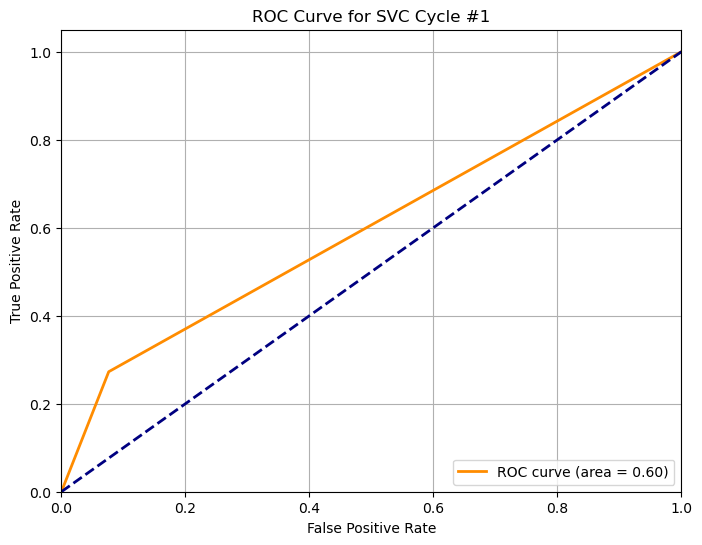

0.5684212907524927
0.5453333333333333
0.5038991695653854
0.4643506887646616
0.4643506887646616
0.4653982762705031
0.5038991695653854
0.48368769563251257
0.5245813951958649
0.44888809207952884
RESULTS FOR CYCLE MLP#1
Accuracy: 0.7683
F1-Score: 0.4062
MCC: 0.2627


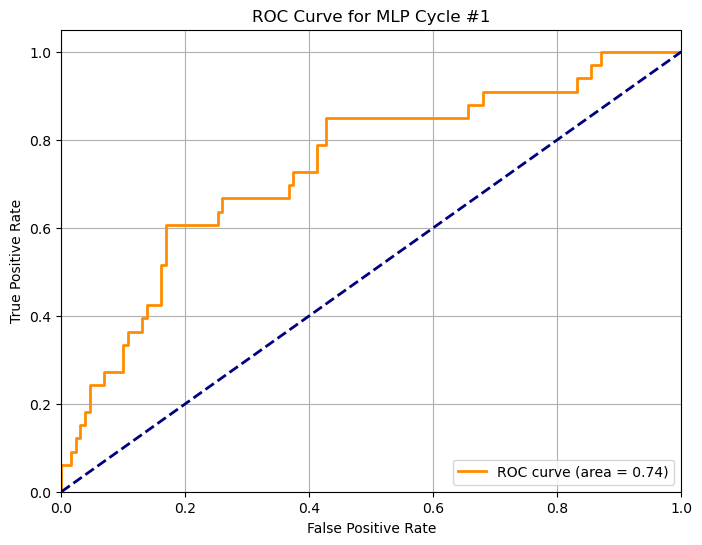

SVC
0.4638888888888889
0.4638888888888889
0.4638888888888889
0.4638888888888889
0.4638888888888889
0.4638888888888889
0.4638888888888889
0.4638888888888889
0.4793489256961887
0.4793489256961887
KNN
0.5024511347953579
0.5024511347953579
0.5024511347953579
0.5024511347953579
0.5024511347953579
0.5024511347953579
0.5024511347953579
0.5024511347953579
0.5024511347953579
0.5024511347953579
RESULTS FOR CYCLE KNN#2
Accuracy: 0.6707
F1-Score: 0.1290
MCC: -0.0732
RESULTS FOR CYCLE SVC#2
Accuracy: 0.7378
F1-Score: 0.2951
MCC: 0.1360


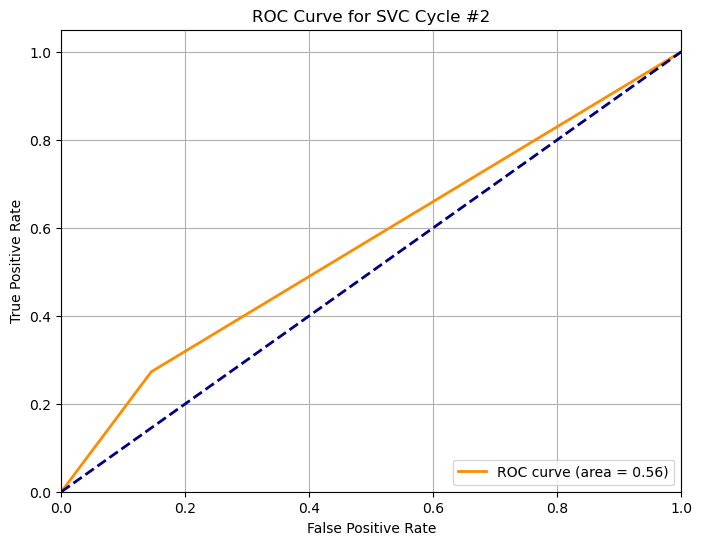

0.5321054706390999
0.5500853928200051
0.48368769563251257
0.4075841866427789
0.4075841866427789
0.43864526472974
0.4842066983091365
0.5245813951958649
0.43957716465519986
0.4648174048083548
RESULTS FOR CYCLE MLP#2
Accuracy: 0.5793
F1-Score: 0.2418
MCC: -0.0213


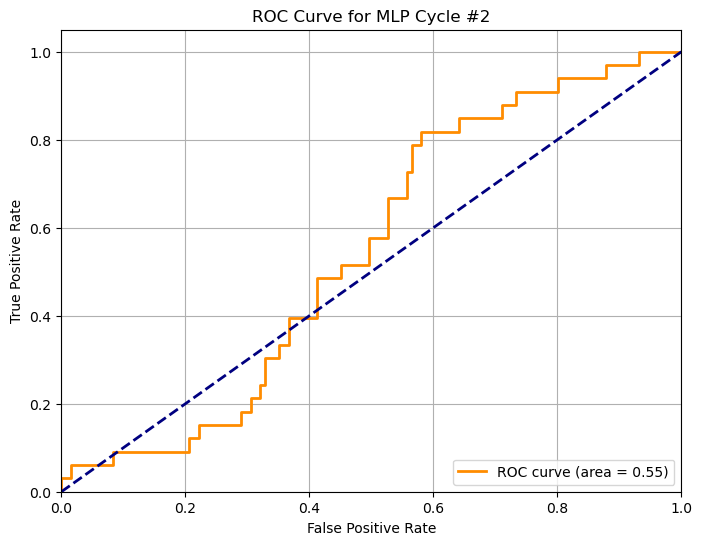

SVC
0.5074074765489208
0.5074074765489208
0.5074074765489208
0.5074074765489208
0.5074074765489208
0.5074074765489208
0.5074074765489208
0.5074074765489208
0.5074074765489208
0.5074074765489208
KNN
0.5421151989096865
0.5421151989096865
0.5421151989096865
0.5421151989096865
0.5421151989096865
0.5421151989096865
0.5421151989096865
0.5421151989096865
0.5421151989096865
0.5421151989096865
RESULTS FOR CYCLE KNN#3
Accuracy: 0.8025
F1-Score: 0.3043
MCC: 0.2455
RESULTS FOR CYCLE SVC#3
Accuracy: 0.8148
F1-Score: 0.2857
MCC: 0.2788


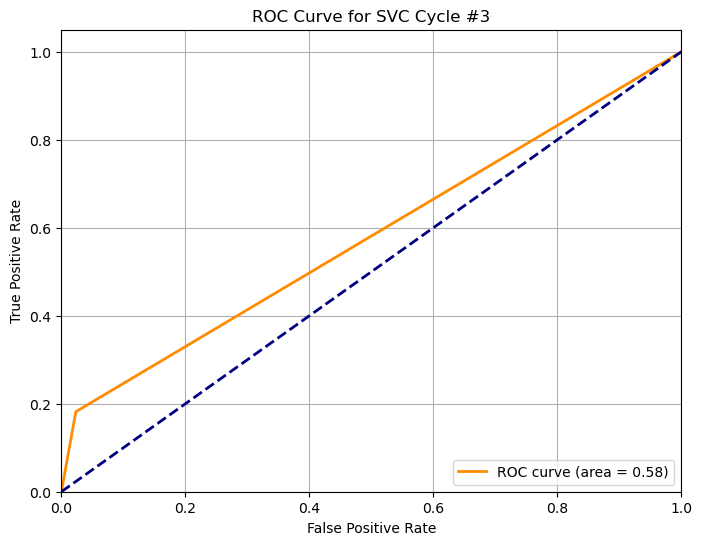

0.5831168703185179
0.46266666666666667
0.5096346630832576
0.4300771855463175
0.4300771855463175
0.48836308060550454
0.619857973936148
0.6450345951582634
0.5096346630832576
0.4842066983091365
RESULTS FOR CYCLE MLP#3
Accuracy: 0.7778
F1-Score: 0.3793
MCC: 0.2506


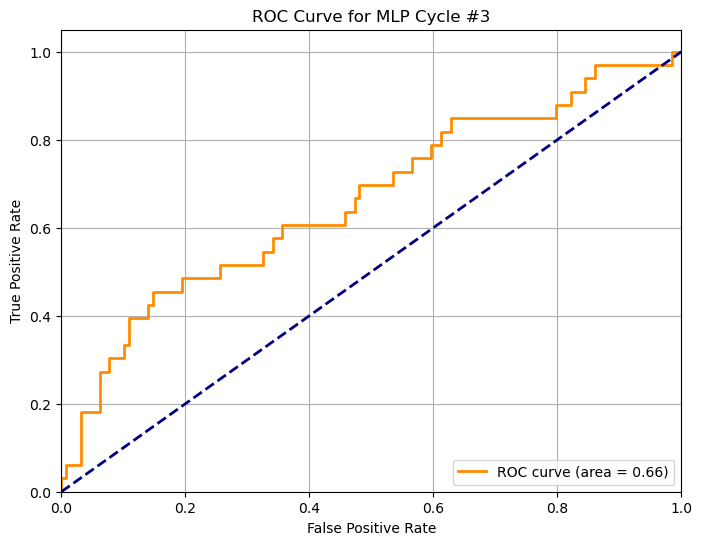

SVC
0.5453333333333333
0.5453333333333333
0.5453333333333333
0.5453333333333333
0.5453333333333333
0.5453333333333333
0.5453333333333333
0.5453333333333333
0.5307227776030219
0.5307227776030219
KNN
0.36226673028138096
0.3926895649523752
0.3926895649523752
0.36226673028138096
0.3926895649523752
0.36226673028138096
0.3926895649523752
0.36226673028138096
0.3926895649523752
0.36226673028138096
RESULTS FOR CYCLE KNN#4
Accuracy: 0.8063
F1-Score: 0.2051
MCC: 0.2246
RESULTS FOR CYCLE SVC#4
Accuracy: 0.7625
F1-Score: 0.2692
MCC: 0.1471


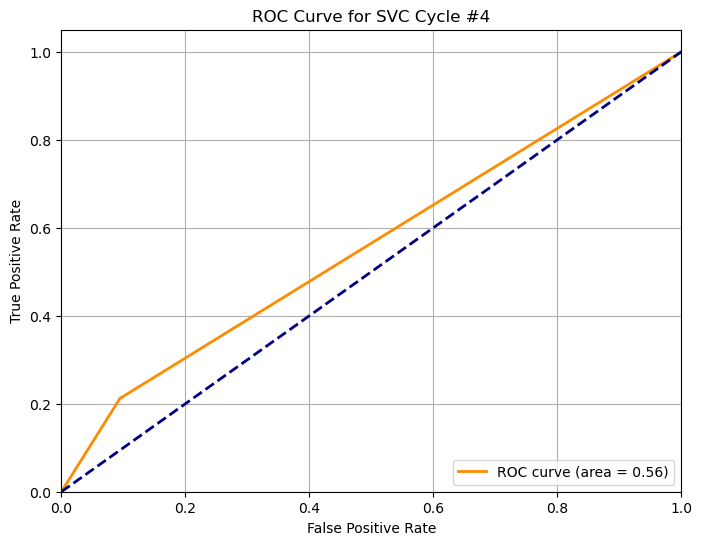

0.5396448772462251
0.4066585835803175
0.5548439107683517
0.45674609602439037
0.45674609602439037
0.5038991695653854
0.5294629064128473
0.5195253045387441
0.4910511396173081
0.42311396068767754
RESULTS FOR CYCLE MLP#4
Accuracy: 0.8313
F1-Score: 0.5714
MCC: 0.4675


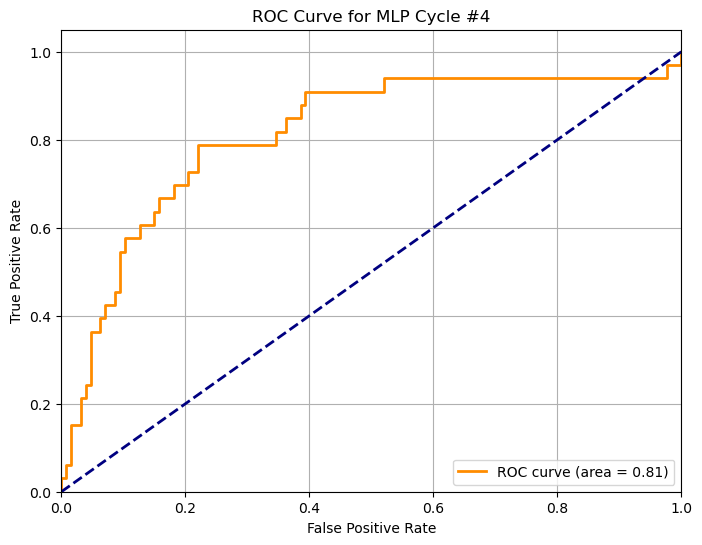

SVC
0.3148213574395854
0.3148213574395854
0.3148213574395854
0.3148213574395854
0.3148213574395854
0.3148213574395854
0.3148213574395854
0.3148213574395854
0.3154739442867026
0.3154739442867026
KNN
0.5695004190655192
0.5695004190655192
0.5695004190655192
0.5695004190655192
0.5695004190655192
0.5695004190655192
0.5695004190655192
0.5695004190655192
0.5695004190655192
0.5695004190655192
RESULTS FOR CYCLE KNN#5
Accuracy: 0.7927
F1-Score: 0.1500
MCC: 0.1197
RESULTS FOR CYCLE SVC#5
Accuracy: 0.7927
F1-Score: 0.2273
MCC: 0.1694


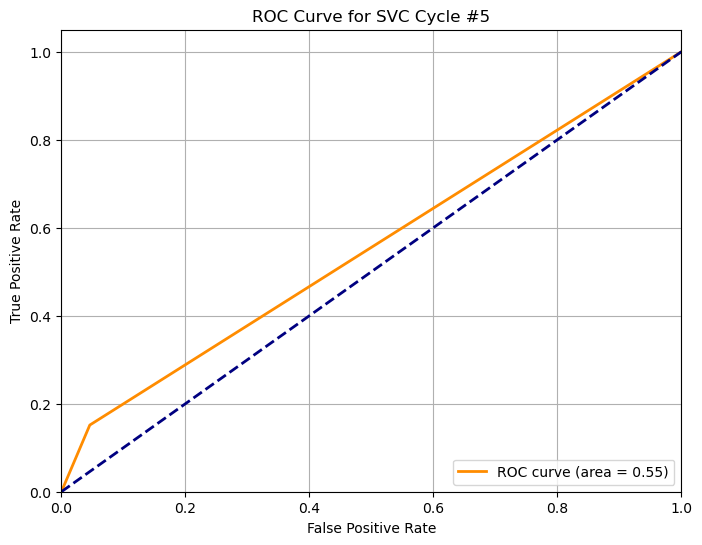

0.5207107044340136
0.3109573032498906
0.45840944278168594
0.3342145968383607
0.3342145968383607
0.44738195080701615
0.44738195080701615
0.49393617459726663
0.43957716465519986
0.36358082718030565
RESULTS FOR CYCLE MLP#5
Accuracy: 0.8110
F1-Score: 0.4561
MCC: 0.3516


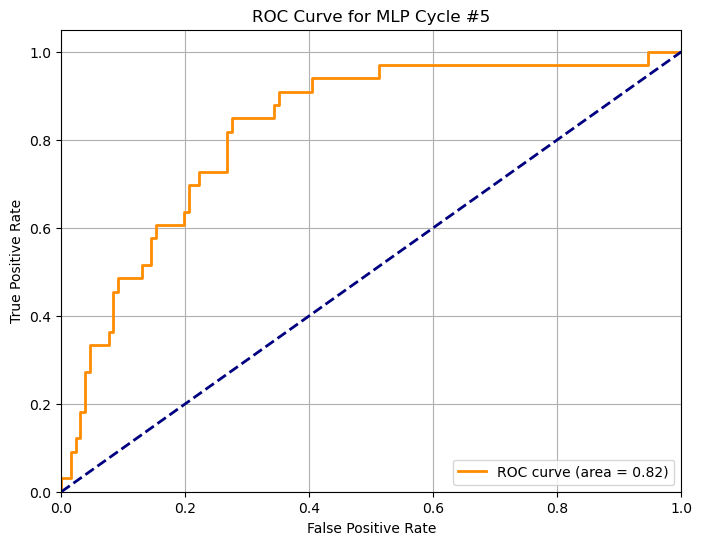

SVC
0.09639588112890256
0.09639588112890256
0.09639588112890256
0.09639588112890256
0.09639588112890256
0.09639588112890256
0.09639588112890256
0.09639588112890256
0.07155522065243071
0.07155522065243071
KNN
0.29327859120102384
0.29327859120102384
0.29327859120102384
0.29327859120102384
0.29327859120102384
0.29327859120102384
0.29327859120102384
0.29327859120102384
0.29327859120102384
0.29327859120102384
RESULTS FOR CYCLE KNN#6
Accuracy: 0.8113
F1-Score: 0.3182
MCC: 0.2883
RESULTS FOR CYCLE SVC#6
Accuracy: 0.7799
F1-Score: 0.2222
MCC: 0.1473


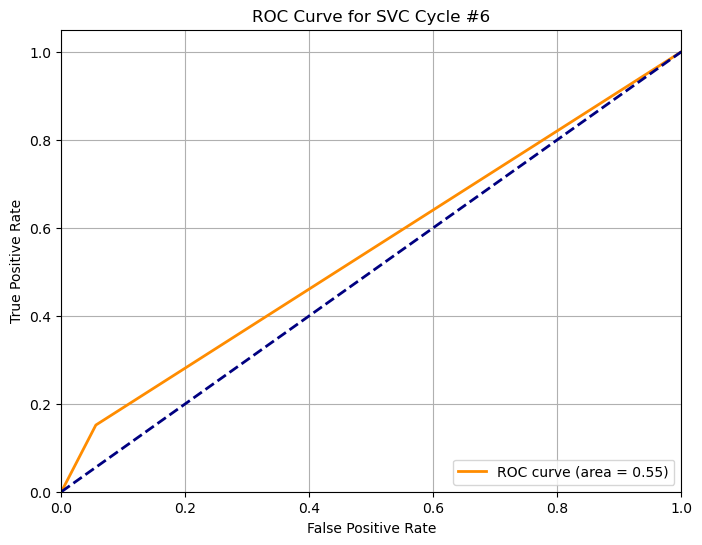

0.2689685595408976
0.3376579678103368
0.35663120737835136
-0.00991515465631671
-0.00991515465631671
0.22167903808275854
0.2513646070494493
0.3464382723765592
0.32931992485002454
0.255978371520363
RESULTS FOR CYCLE MLP#6
Accuracy: 0.8050
F1-Score: 0.5753
MCC: 0.4538


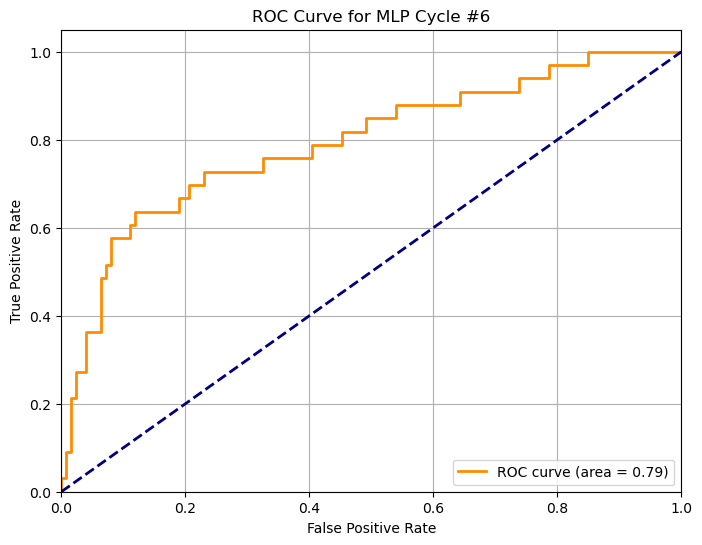

SVC
0.19343690654098097
0.19343690654098097
0.19343690654098097
0.19343690654098097
0.19343690654098097
0.19343690654098097
0.19343690654098097
0.19343690654098097
0.20749731298014656
0.20749731298014656
KNN
0.2136178818966545
0.2136178818966545
0.2136178818966545
0.2136178818966545
0.2136178818966545
0.2136178818966545
0.2136178818966545
0.2136178818966545
0.2136178818966545
0.2136178818966545
RESULTS FOR CYCLE KNN#7
Accuracy: 0.8141
F1-Score: 0.3556
MCC: 0.3063
RESULTS FOR CYCLE SVC#7
Accuracy: 0.7436
F1-Score: 0.2308
MCC: 0.0901


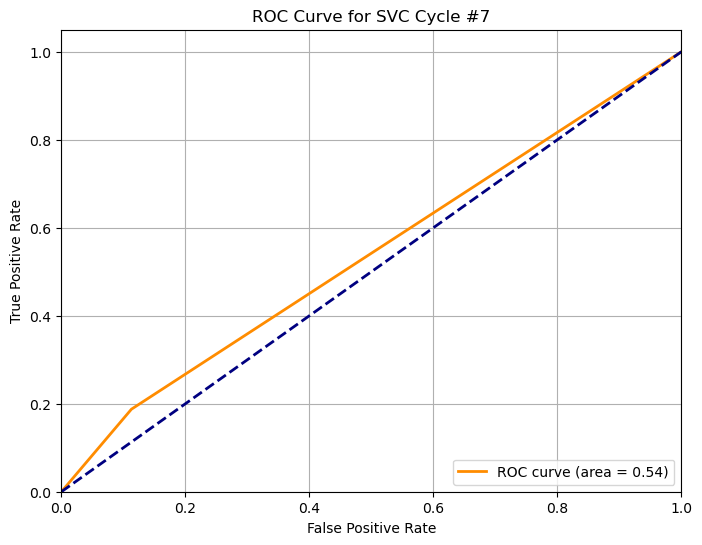

0.24098190278081716
0.2534082108695355
0.23186944788008415
0.009330232985824282
0.009330232985824282
0.3378493041946496
0.1755204850569111
0.26802198035672026
0.16316852193930234
0.2351115040886743
RESULTS FOR CYCLE MLP#7
Accuracy: 0.5192
F1-Score: 0.2857
MCC: 0.0008


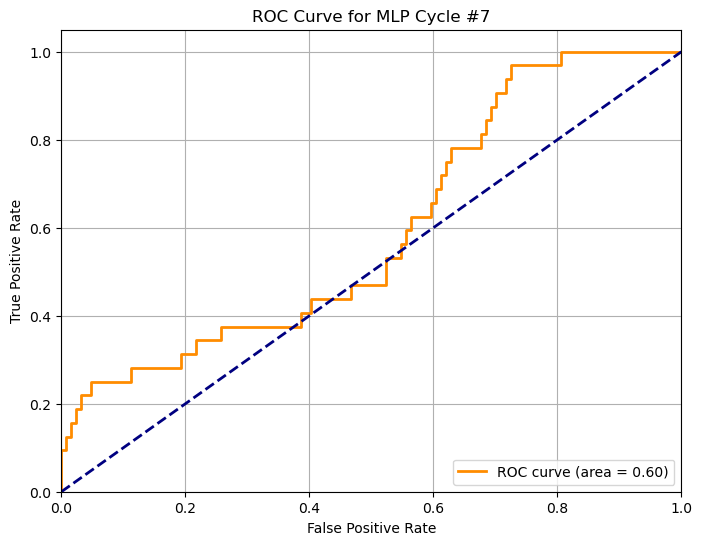

SVC
0.3309259191867206
0.3309259191867206
0.3309259191867206
0.3309259191867206
0.3309259191867206
0.3309259191867206
0.3309259191867206
0.3309259191867206
0.3154739442867026
0.3154739442867026
KNN
0.2444175785795206
0.2444175785795206
0.2444175785795206
0.2444175785795206
0.2444175785795206
0.2444175785795206
0.2444175785795206
0.2444175785795206
0.2444175785795206
0.2444175785795206
RESULTS FOR CYCLE KNN#8
Accuracy: 0.7736
F1-Score: 0.0526
MCC: -0.0034
RESULTS FOR CYCLE SVC#8
Accuracy: 0.7799
F1-Score: 0.2222
MCC: 0.1473


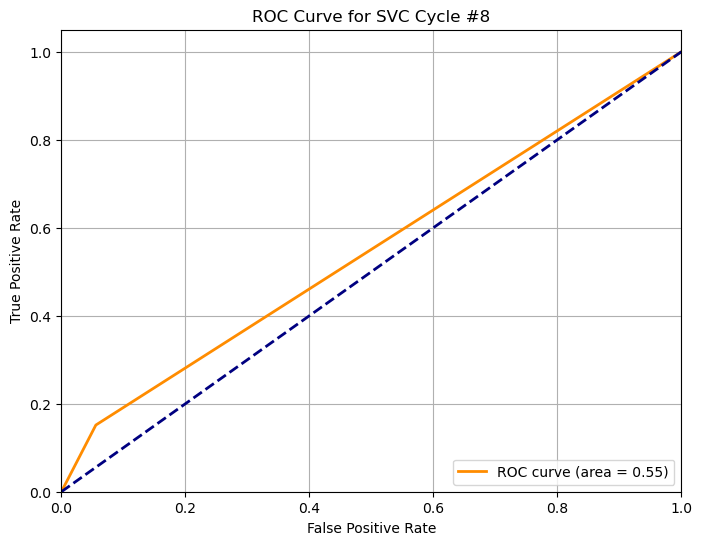

0.36979461558228716
-0.025531389540169015
0.49885805365511243
-0.03333333333333333
-0.03333333333333333
0.3782508796203137
0.4215416175710225
0.4361524558479971
0.4042199401560136
0.39553219121294575
RESULTS FOR CYCLE MLP#8
Accuracy: 0.7484
F1-Score: 0.4872
MCC: 0.3326


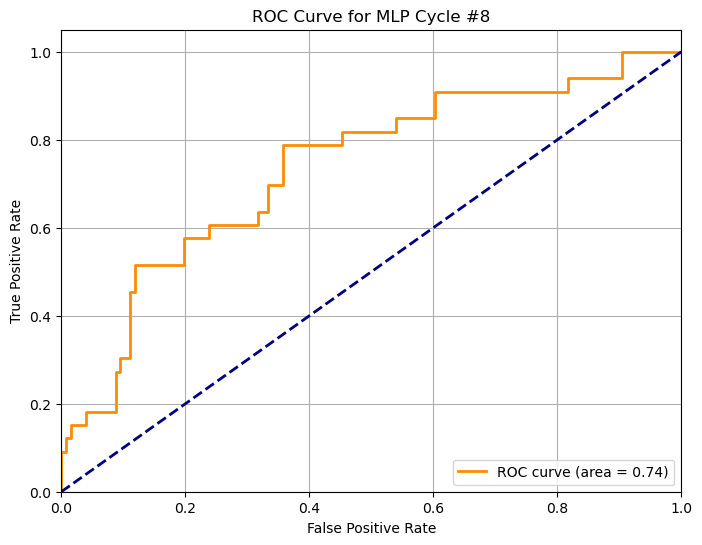

SVC
0.5764386444017885
0.5764386444017885
0.5764386444017885
0.5764386444017885
0.5764386444017885
0.5764386444017885
0.5764386444017885
0.5764386444017885
0.5421151989096865
0.5421151989096865
KNN
0.4722956217664421
0.4997977200073261
0.4997977200073261
0.4722956217664421
0.4997977200073261
0.4722956217664421
0.4997977200073261
0.4722956217664421
0.4997977200073261
0.4722956217664421
RESULTS FOR CYCLE KNN#9
Accuracy: 0.7950
F1-Score: 0.1951
MCC: 0.1671
RESULTS FOR CYCLE SVC#9
Accuracy: 0.7888
F1-Score: 0.2609
MCC: 0.1884


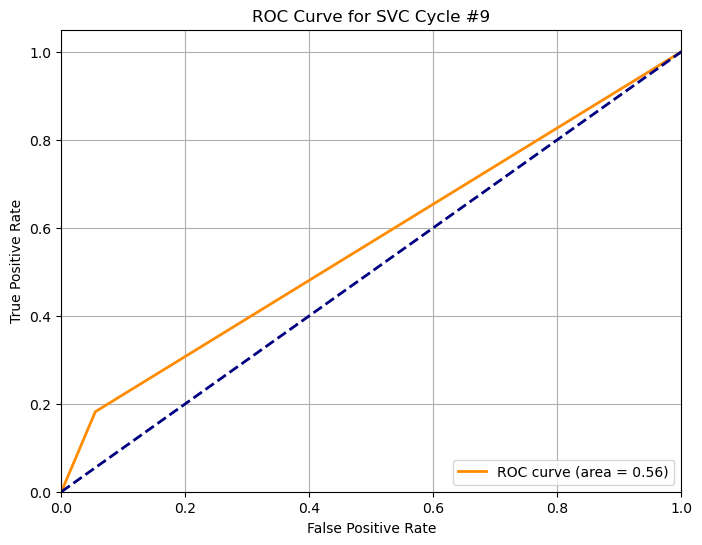

0.0
0.47680939526834504
0.5294629064128473
0.43107187893233845
0.43107187893233845
0.45840944278168594
0.5038991695653854
0.5813203897855763
0.5245813951958649
0.4643506887646616
RESULTS FOR CYCLE MLP#9
Accuracy: 0.7391
F1-Score: 0.3438
MCC: 0.1813


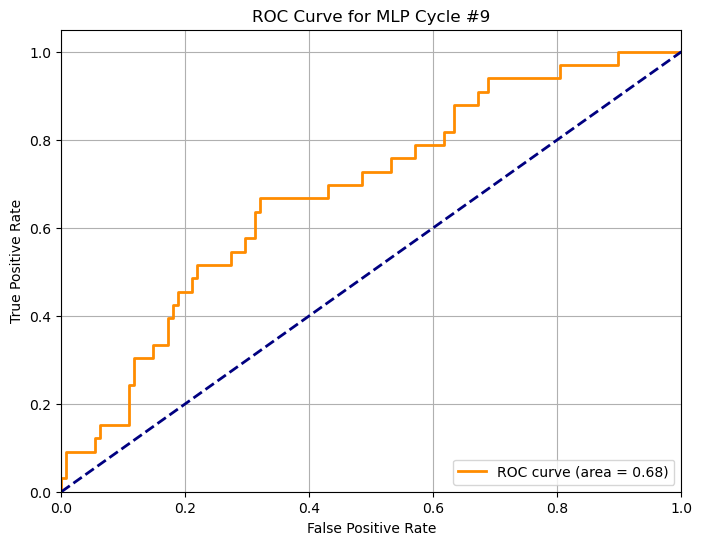

SVC
0.3611451321167335
0.3611451321167335
0.3611451321167335
0.3611451321167335
0.3611451321167335
0.3611451321167335
0.3611451321167335
0.3611451321167335
0.39292905195125133
0.39292905195125133
KNN
0.2898223537100483
0.2898223537100483
0.2898223537100483
0.2898223537100483
0.2898223537100483
0.2898223537100483
0.2898223537100483
0.2898223537100483
0.2898223537100483
0.2898223537100483
RESULTS FOR CYCLE KNN#10
Accuracy: 0.8148
F1-Score: 0.3478
MCC: 0.3019
RESULTS FOR CYCLE SVC#10
Accuracy: 0.8148
F1-Score: 0.2857
MCC: 0.2788


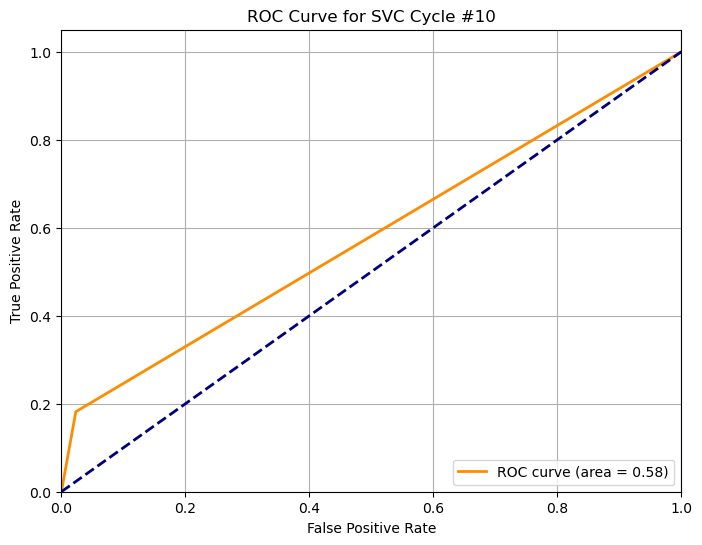

0.3697866384190773
0.16649102041075248
0.42206656961033295
0.25970758301180796
0.25970758301180796
0.39103798742006707
0.3595813557612193
0.4021234836959025
0.4275483117136258
0.3889716418008673
RESULTS FOR CYCLE MLP#10
Accuracy: 0.8025
F1-Score: 0.4483
MCC: 0.3355


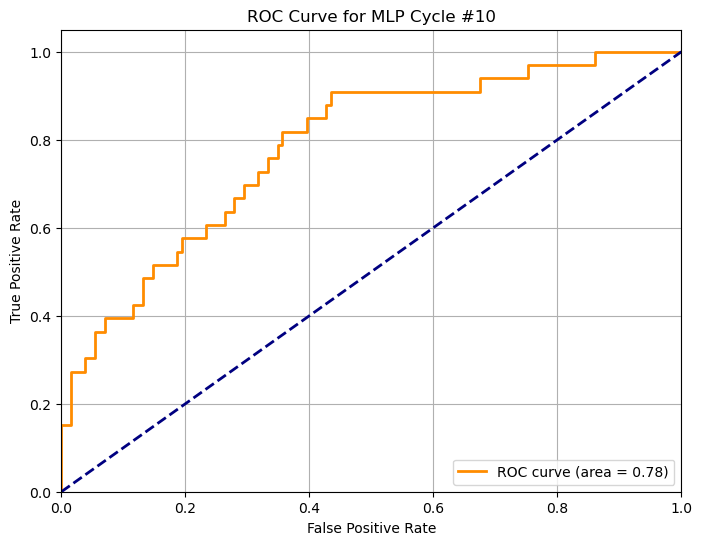

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# --- Metrics and plotting libraries ---
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []

# --- Your main loop starts here ---
for i in range(1,11):
    # Assuming 'mod_data' directory and files exist for demonstration
    # For a runnable example, you might need to create dummy CSV files
    # For instance:
    # pd.DataFrame(np.random.rand(100, 10)).to_csv(f"mod_data/X1.{i}", index_label="QSPRID")
    # pd.DataFrame(np.random.randint(0, 2, 100)).to_csv(f"mod_data/y1.{i}", index_label="QSPRID")
    # ... similarly for X2, X3, y2, y3
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")



    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()

    print("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        j["gamma"]= j["gamma"] if j["gamma"] == 'auto' or j["gamma"] == 'scale' else float(j["gamma"])
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred) # pred is already binary for SVC.predict
        print(mcc)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)
    # Get binary predictions

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    print("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        print(mcc)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.

    pred = pred_test_knn[-1]
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE KNN#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)

    pred = pred_test_svc[-1]
    # SVC.predict returns binary labels, so pred_proba for ROC needs svc.decision_function or svc.predict_proba
    # For simplicity, if you only have predict, you can use the binary prediction for ROC, but it won't be smooth.
    # If SVC was trained with probability=True, you could use svc.predict_proba(x3)[:, 1]
    # For now, let's assume pred is already binary for metrics and use it for ROC (though not ideal for a smooth curve)
    pred_proba_svc = pred # Using binary prediction as "probability" for ROC, not ideal but avoids error
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE SVC#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)
    # Calculate ROC curve and AUC
    # Note: For a proper ROC curve, you need probabilities, not binary predictions.
    # If SVC was initialized with `probability=True`, you could use `svc.predict_proba(x3)[:, 1]`.
    # As it is, `pred` is binary, so `roc_curve` will produce a step function.
    fpr, tpr, thresholds = roc_curve(y3, pred_proba_svc)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for SVC Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    for j in best_results_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        # Ensure 'cuda' is available or use 'cpu'
        device = "cuda" if torch.cuda.is_available() else "cpu"
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device=device, **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        # mlp.predict returns probabilities, so thresholding is needed for MCC
        pred_val_mlp_prob = mlp.predict(x2)
        pred = (pred_val_mlp_prob > 0.5).astype(int) # Convert boolean to int (0 or 1)
        mcc = matthews_corrcoef(y2, pred)
        print(mcc)
        if mcc > best_mcc_this_run_mlp: # Changed from best_mcc_this_run to best_mcc_this_run_mlp
            best_mcc_this_run_mlp = mcc
            best_val_results_this_run_mlp = pred_val_mlp_prob # Store probabilities
            best_test_results_this_run_mlp = mlp.predict(x3) # Store probabilities
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)
    # Get binary predictions


    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.
    pred_proba = np.array(pred_test_mlp[-1]) # Convert the list to a NumPy array for element-wise comparison
    pred = (pred_proba > 0.5).astype(int) # Convert boolean to int (0 or 1)
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE MLP#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    # Calculate ROC curve and AUC
    # pred_proba is already probabilities, so it's suitable for roc_curve
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for MLP Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show() # This will display the plot for the current cycle

    print("="*30)
    # --- End: New code ---
    # --- End: New code ----



In [31]:
best_results_mlp_dicts

[{'dropout_frac': 0.6759400943801049,
  'patience': 37,
  'tol': 3.0888435964774785e-05,
  'weight_decay': 0.0023299518105153,
  'n_epochs': 1233,
  'batch_size': 128,
  'optimizer': torch.optim.adamw.AdamW,
  'lr': 0.001,
  'neuron_layers': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]},
 {'dropout_frac': 0.7194038137191613,
  'patience': 22,
  'tol': 0.0002947051702551,
  'weight_decay': 0.0059636233165946,
  'n_epochs': 1306,
  'batch_size': 512,
  'optimizer': torch.optim.adamw.AdamW,
  'lr': 0.0001,
  'neuron_layers': [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]},
 {'dropout_frac': 0.3357987184952232,
  'patience': 128,
  'tol': 0.0049417133613238,
  'weight_decay': 3.39322177189533e-05,
  'n_epochs': 1687,
  'batch_size': 64,
  'optimizer': torch.optim.adamw.AdamW,
  'lr': 0.0001,
  'neuron_layers': [4096,
   3072,
   2048,
   1536,
   1024,
   768,
   512,
   256,
   128,
   64,
   32,
   16,
   8]},
 {'dropout_frac': 0.8793824647259006,
  'patience': 75,
  'tol': 0.00

In [32]:
all_y3 =[]
mcc_list = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    mcc_list.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [33]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []

for i in range(1,11):
    print("-----", i, "-----")
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    smote = SMOTE(sampling_strategy=1, random_state=42)
    x1, y1 = smote.fit_resample(x1, y1)

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()
    display("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred > 0.5)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    display("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    display("MLP")
    for j in best_results_mlp_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device="cuda", **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        pred = mlp.predict(x2)>0.5
        mcc = matthews_corrcoef(y2, pred)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run_mlp = mlp.predict(x2)
            best_test_results_this_run_mlp = mlp.predict(x3)
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)








[array([[0.24588943],
        [0.25017506],
        [0.24590655],
        [0.24841438],
        [0.24685085],
        [0.24452762],
        [0.26764232],
        [0.24542682],
        [0.26522666],
        [0.24638207],
        [0.2453288 ],
        [0.24565686],
        [0.24531697],
        [0.24810603],
        [0.24515942],
        [0.24595813],
        [0.7941203 ],
        [0.2453032 ],
        [0.7226659 ],
        [0.8687862 ],
        [0.78222483],
        [0.24687886],
        [0.2472588 ],
        [0.24573533],
        [0.7875237 ],
        [0.25244817],
        [0.24597196],
        [0.25869364],
        [0.2480663 ],
        [0.2463857 ],
        [0.2445555 ],
        [0.29276708],
        [0.24824442],
        [0.7539448 ],
        [0.24490047],
        [0.24562988],
        [0.24430941],
        [0.24762659],
        [0.24478106],
        [0.46354643],
        [0.24413499],
        [0.8589408 ],
        [0.24663197],
        [0.24640326],
        [0.8412942 ],
        [0

In [34]:
display(all_y3)

[QSPRID
 A2ARDataset_000    False
 A2ARDataset_001    False
 A2ARDataset_002    False
 A2ARDataset_003     True
 A2ARDataset_004    False
                    ...  
 A2ARDataset_159     True
 A2ARDataset_160     True
 A2ARDataset_161    False
 A2ARDataset_162    False
 A2ARDataset_163     True
 Name: Y, Length: 164, dtype: bool,
 QSPRID
 CK1Dataset_000    False
 CK1Dataset_001     True
 CK1Dataset_002    False
 CK1Dataset_003    False
 CK1Dataset_004     True
                   ...  
 CK1Dataset_159     True
 CK1Dataset_160    False
 CK1Dataset_161     True
 CK1Dataset_162    False
 CK1Dataset_163     True
 Name: Y, Length: 164, dtype: bool,
 QSPRID
 CK1Dataset_000    False
 CK1Dataset_001     True
 CK1Dataset_002    False
 CK1Dataset_003    False
 CK1Dataset_004    False
                   ...  
 CK1Dataset_157    False
 CK1Dataset_158     True
 CK1Dataset_159     True
 CK1Dataset_160    False
 CK1Dataset_161     True
 Name: Y, Length: 162, dtype: bool,
 QSPRID
 CK1Dataset_000     True

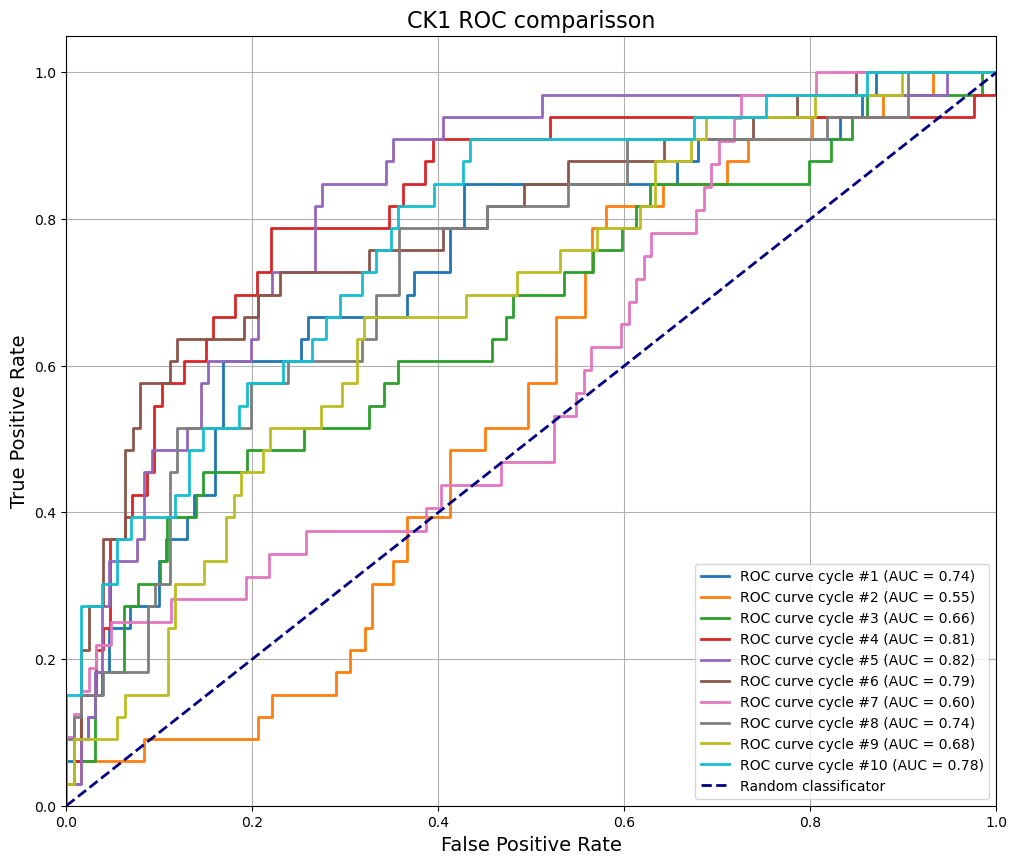

In [35]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"



plt.figure(figsize=(12, 10))

# Projdeme všechny uložené predikce a skutečné hodnoty
for i in range(len(pred_test_mlp)):
    
    # Získáme data pro i-tý cyklus
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    # Vypočítáme ROC křivku a AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Vykreslíme křivku pro tento cyklus do společného grafu
    # (i + 2) použijeme pro správné číslování cyklů, protože váš cyklus začínal od 2
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

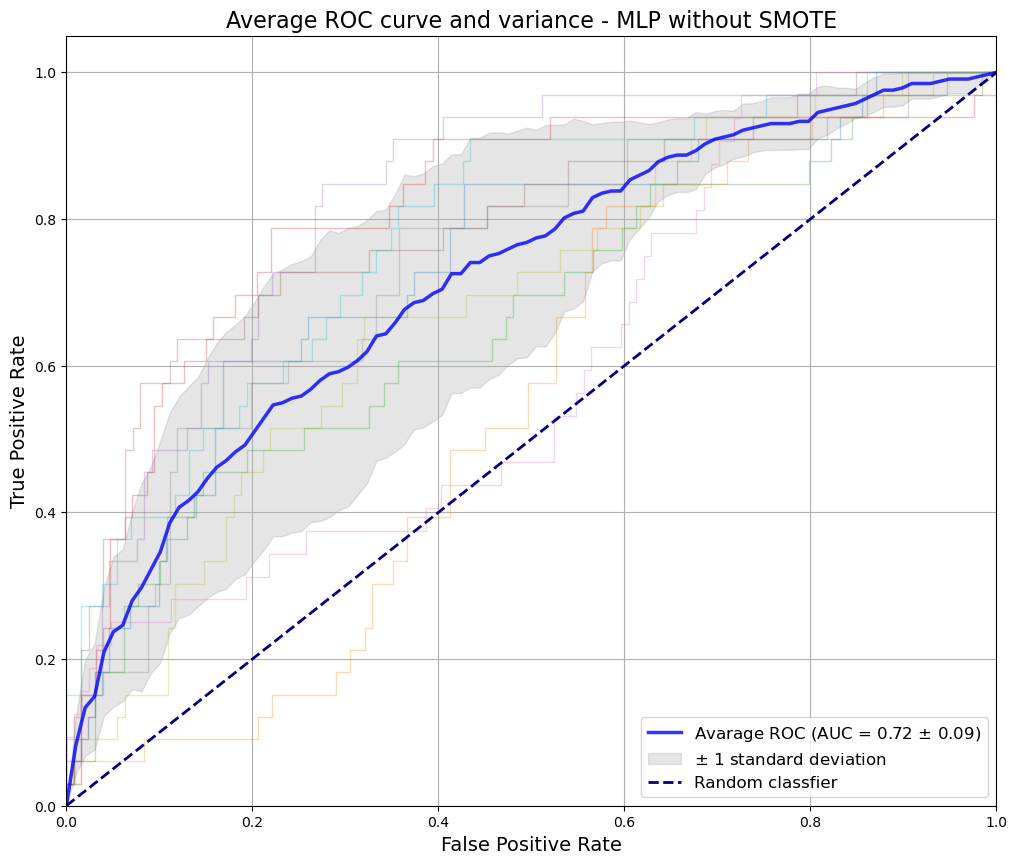

In [49]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('mcc_roc_ck1_ws.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
all_y3_knn =[]
mcc_list_knn = []
f1_list_knn = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn.append(y_test)
    f1_list_knn.append(f1_score(y_test, (pred_test_knn[i-1]>0.5)))
    mcc_list_knn.append(matthews_corrcoef(y_test, (pred_test_knn[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [45]:
all_y3_mlp =[]
mcc_list_mlp = []
f1_list_mlp = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_mlp.append(y_test)
    f1_list_mlp.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list_mlp.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))
    print(mcc_list_mlp[-1])

1
0.26268317748120334
2
-0.021336989228845023
3
0.2506281363689491
4
0.4674882183470144
5
0.35159487979323883
6
0.45382728197251787
7
0.000815781182587399
8
0.3325755290701754
9
0.18129553989943498
10
0.33548029539041146


In [46]:
all_y3_svc =[]
mcc_list_svc = []
f1_list_svc = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc.append(y_test)
    f1_list_svc.append(f1_score(y_test, (pred_test_svc[i-1]>0.5)))
    mcc_list_svc.append(matthews_corrcoef(y_test, (pred_test_svc[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


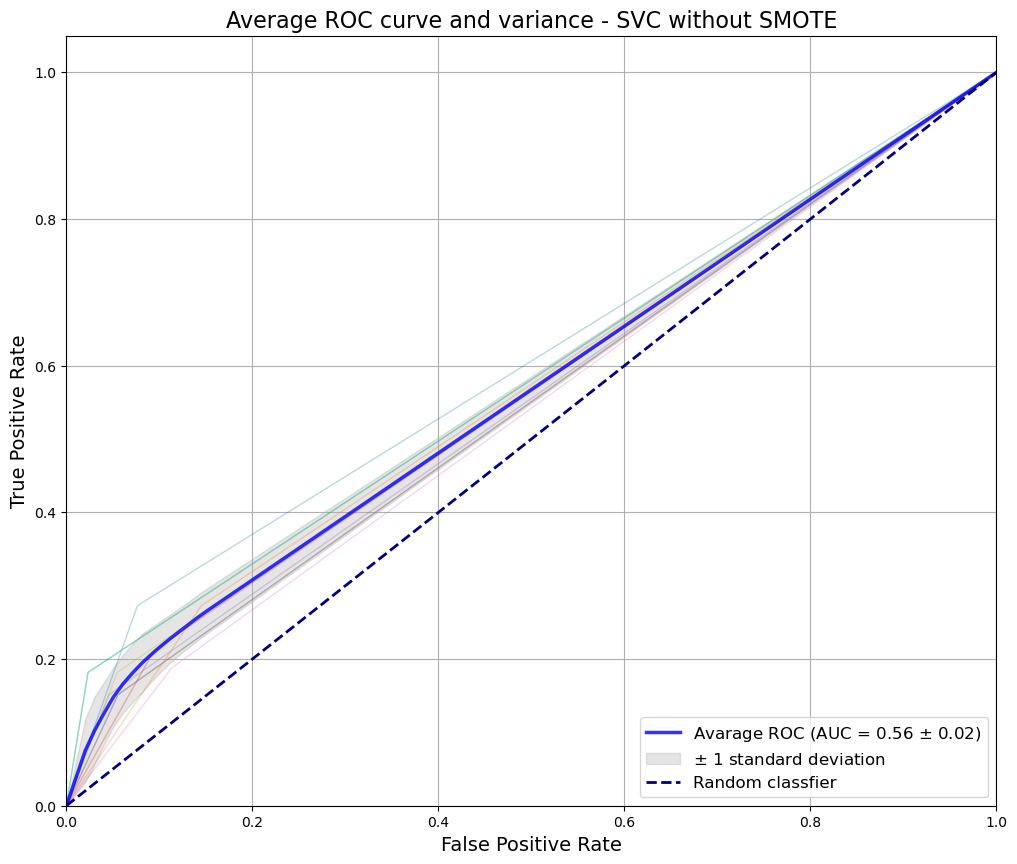

In [40]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3_svc[i]
    y_pred_proba = pred_test_svc[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - SVC without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()

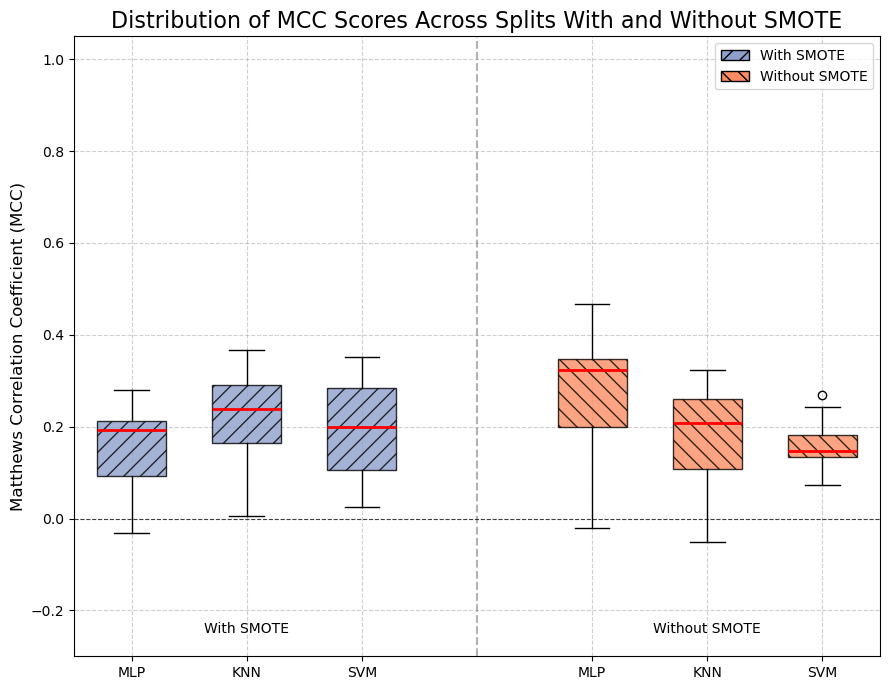

In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(9, 7))

# Data
data = [mcc_list_mlp, mcc_list_knn, mcc_list_svc,
        mcc_list_mlp_ws, mcc_list_knn_ws, mcc_list_svc_ws]

# Vlastní pozice pro mezery mezi skupinami
positions = [1, 2, 3, 5, 6, 7]

# Vykreslení boxplotu na definovaných pozicích
bplot = plt.boxplot(data,
                    positions=positions,
                    patch_artist=True,
                    widths=0.6)

# Barvy a šrafování
smote_color = '#8da0cb'
non_smote_color = '#fc8d62'
smote_hatch = '//'
non_smote_hatch = '\\\\'
median_color = 'red'

# Úprava boxů
for i, box in enumerate(bplot['boxes']):
    if i < 3:
        box.set_facecolor(smote_color)
        box.set_hatch(smote_hatch)
    else:
        box.set_facecolor(non_smote_color)
        box.set_hatch(non_smote_hatch)
    box.set_edgecolor('black')
    box.set_alpha(0.8)

# Mediány
for median in bplot['medians']:
    median.set_color(median_color)
    median.set_linewidth(2)

# X-osa – popisky
plt.xticks([1, 2, 3, 5, 6, 7], ['MLP', 'KNN', 'SVM', 'MLP', 'KNN', 'SVM'])

# Oddělující čára mezi skupinami
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.6)
plt.text(2, -0.25, 'With SMOTE', ha='center', fontsize=10)
plt.text(6, -0.25, 'Without SMOTE', ha='center', fontsize=10)

# Titulek a osy
plt.title('Distribution of MCC Scores Across Splits With and Without SMOTE', fontsize=16)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
plt.ylim([-0.3, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Add a horizontal line at MCC = 0
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Legenda
smote_patch = mpatches.Patch(facecolor=smote_color, edgecolor='black', hatch=smote_hatch, label='With SMOTE')
non_smote_patch = mpatches.Patch(facecolor=non_smote_color, edgecolor='black', hatch=non_smote_hatch, label='Without SMOTE')
plt.legend(handles=[smote_patch, non_smote_patch], loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('mcc_boxplot_ck1.png', dpi=300, bbox_inches='tight')
plt.show()


In [69]:
display(mcc_list_knn)

[0.36669454141239677,
 0.04346601729901178,
 0.0061747965158871305,
 0.1480815848997555,
 0.2783846906609838,
 0.2506970438905309,
 0.2140462608328655,
 0.22677216045305917,
 0.2942074616088126,
 0.33637220719324384]

In [70]:
display(mcc_list_svc)

[0.1905198432638073,
 0.0552086249707639,
 0.07806259944213187,
 0.1874534328026514,
 0.2702239455289357,
 0.28826493717718243,
 0.340379871900178,
 0.20603578944537568,
 0.02550793665979526,
 0.3508690026946019]

In [71]:
display(mcc_list_mlp)

[0.1905198432638073,
 0.05179579395086427,
 -0.032105718724445086,
 0.2095969026693416,
 0.21297173419325544,
 0.1925493100306566,
 0.2299084675051709,
 0.1939441363585449,
 0.060581636722749785,
 0.28081438423200855]

In [72]:
display(mcc_list_mlp_ws)

[0.31328350760778406,
 -0.021336989228845023,
 0.2506281363689491,
 0.4674882183470144,
 0.35159487979323883,
 0.45382728197251787,
 0.000815781182587399,
 0.3325755290701754,
 0.18129553989943498,
 0.33548029539041146]

In [43]:
[mcc_list_mlp, mcc_list_knn, mcc_list_svc]

[[0.26268317748120334,
  -0.021336989228845023,
  0.2506281363689491,
  0.4674882183470144,
  0.35159487979323883,
  0.45382728197251787,
  0.000815781182587399,
  0.3325755290701754,
  0.18129553989943498,
  0.33548029539041146],
 [0.08792480672065253,
  -0.07316577794126737,
  0.2455118628324273,
  0.22460915465170275,
  0.11974269912232974,
  0.28826493717718243,
  0.3063358324269934,
  -0.003353232334378716,
  0.16712096432279652,
  0.30192735471732546],
 [0.2460108552930142,
  0.13604982582081104,
  0.2787949980076138,
  0.1471301684021711,
  0.16942657217386592,
  0.14732666664642455,
  0.09009930216419205,
  0.14732666664642455,
  0.18836915825000328,
  0.2787949980076138]]

In [47]:
[f1_list_mlp, f1_list_knn, f1_list_svc]

[[0.40625,
  0.24175824175824176,
  0.3793103448275862,
  0.5714285714285714,
  0.45614035087719296,
  0.5753424657534246,
  0.2857142857142857,
  0.48717948717948717,
  0.34375,
  0.4482758620689655],
 [0.10526315789473684,
  0.12903225806451613,
  0.30434782608695654,
  0.20512820512820512,
  0.15,
  0.3181818181818182,
  0.35555555555555557,
  0.05263157894736842,
  0.1951219512195122,
  0.34782608695652173],
 [0.34615384615384615,
  0.29508196721311475,
  0.2857142857142857,
  0.2692307692307692,
  0.22727272727272727,
  0.2222222222222222,
  0.23076923076923078,
  0.2222222222222222,
  0.2608695652173913,
  0.2857142857142857]]